In [1]:
import ast
import glob
import json
import math
import os
import pathlib

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import linregress
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sympy.printing.pretty.pretty_symbology import line_width

from src.datasets.base_dataset import gender_mapping, ethnicity_mapping
from src.evaluation import eval_analysis
from src.hpo_tree.hpo_model import HumanPhenotypeModel, create_model
from src.hpo_tree.hpo_term import HumanPhenotypeTerm
from src.utils.mediapipe_helper import extract_face_meshes
from src.utils.preprocess import procrustes_align

plt.style.use('default')

In [2]:
publication_dir = 'publication'
os.makedirs(publication_dir, exist_ok=True)

df_hpo_annotation = pd.read_csv('data/Face2HPO-181120251320.csv')
df_gmdb = pd.read_csv(os.path.join('data', 'gmdb_data_v110.csv'), low_memory=False)

images_annotated = set(df_hpo_annotation['image_id'].tolist())
images_available = set(df_gmdb['image_id'].tolist())

print(f'Images from the hpo annotation dataset overlapping with the GMDB dataset: {len(images_available.intersection(images_annotated))}')
print(f'Images not in GMDB: {sorted(images_annotated - images_available)}')

df_merged = pd.read_csv('data/gmdb_hpo_facemesh_data_v110.csv')
df_reduced = df_merged[df_merged['image_id'].isin(images_annotated)]
print(f'Number of train/val images: ', len(df_reduced))
print(f'Patients with multiple images: {df_reduced[df_reduced['patient_id'].duplicated()]['patient_id'].unique().tolist()}')
train_val_disorders = df_reduced['internal_syndrome_name'].unique().tolist()
train_val_disorders

Images from the hpo annotation dataset overlapping with the GMDB dataset: 1304
Images not in GMDB: [55, 5938, 6444, 6445, 6447, 8934, 8938, 10421, 11629, 11632, 11633, 11634, 12528, 13470, 13741, 14135, 14182, 14395, 14414, 14492, 14577, 14611, 14639, 14677, 15271, 15275, 15313, 15807, 15809, 15821, 15822, 15823, 15824, 15826, 15830, 15832, 15833, 15834, 15836, 15837, 15838, 15839, 15843, 15844, 15845, 15846, 15903, 15904, 15919, 15943, 16019, 16020, 16024, 16025, 16026, 16035, 16239, 16247, 16423, 16488, 16566, 16588, 16687, 16797, 16802, 16923, 18608, 19217, 19221, 19229, 19237, 19291, 19292, 19293, 19295, 19296, 19297, 19299, 19300, 19301, 19308, 19309, 19310, 19311, 19338, 19361, 19479, 19485, 19486, 19490, 19526, 19550, 19551, 19552, 19642, 19709, 19710, 19712, 19716, 19718, 19719, 19721, 19723, 19725, 19727, 19729, 19730, 19731, 19732, 19734, 19738, 19739, 19741, 19845, 19847, 20107, 20119, 20121, 20124, 20126, 20127, 20128, 20129, 20135, 20137, 20138, 20139, 20143, 20226, 20228,

['WILLIAMS-BEUREN SYNDROME; WBS',
 'Cornelia de Lange syndrome',
 'Hypoplastic left heart syndrome',
 'Kabuki syndrome',
 'Noonan syndrome',
 'Noonan syndrome-like disorder with loose anagen hair',
 'KBG SYNDROME; KBGS',
 'Coffin-Siris syndrome',
 'SCHAAF-YANG SYNDROME; SHFYNG',
 'Mucopolysaccharidoses',
 'Hyperphosphatasia with mental retardation syndrome',
 'OGDEN SYNDROME; OGDNS',
 'ANGELMAN SYNDROME; AS',
 'Waardenburg syndrome']

In [3]:
output_dir = 'X:/hellmafa/facemeshsyndromes/output'
df_pointnet = eval_analysis(output_dir)
df_pointnet

100%|██████████| 72/72 [00:23<00:00,  3.12it/s]


,HPO,experiment,accuracy,auroc,f1_score,jaccard_index,matthews_corrcoef,precision,recall,stat_scores/tp,stat_scores/fp,stat_scores/tn,stat_scores/fn,stat_scores/sup,support
8450,HP:0000426,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.90 ± 0.08,0.90 ± 0.08,0.91 ± 0.06,0.83 ± 0.10,0.81 ± 0.13,0.86 ± 0.12,0.97 ± 0.06,7.40 ± 1.14,1.40 ± 1.52,6.20 ± 1.30,0.20 ± 0.45,7.60 ± 1.14,76.0
5391,HP:0000426,db=4_d=3_f=False_m=[age+gender+ethnicity]_t=0....,0.89 ± 0.07,0.89 ± 0.07,0.89 ± 0.07,0.82 ± 0.13,0.79 ± 0.15,0.86 ± 0.09,0.94 ± 0.08,7.20 ± 1.48,1.20 ± 0.84,6.40 ± 1.14,0.40 ± 0.55,7.60 ± 1.14,76.0
4992,HP:0000426,db=4_d=3_f=False_m=[age+gender+ethnicity]_t=0....,0.87 ± 0.01,0.87 ± 0.01,0.88 ± 0.02,0.78 ± 0.03,0.75 ± 0.03,0.82 ± 0.05,0.95 ± 0.07,7.20 ± 1.30,1.60 ± 0.55,6.00 ± 0.00,0.40 ± 0.55,7.60 ± 1.14,76.0
5923,HP:0000426,db=4_d=3_f=False_m=[]_t=0.01_l=0.05_s=42,0.84 ± 0.12,0.84 ± 0.13,0.87 ± 0.09,0.77 ± 0.15,0.72 ± 0.21,0.79 ± 0.15,0.97 ± 0.06,7.40 ± 1.14,2.20 ± 1.92,5.40 ± 2.07,0.20 ± 0.45,7.60 ± 1.14,76.0
119,HP:0100840,db=4_d=2_f=False_m=[age+gender+ethnicity]_t=0....,0.86 ± 0.06,0.86 ± 0.06,0.87 ± 0.06,0.77 ± 0.09,0.73 ± 0.12,0.84 ± 0.06,0.90 ± 0.06,64.40 ± 5.94,12.40 ± 5.59,59.20 ± 5.26,7.20 ± 4.15,71.60 ± 6.23,716.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6140,HP:0000687,db=4_d=3_f=False_m=[]_t=0.05_l=0.00_s=42,0.53 ± 0.23,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.11 ± 0.42,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,5.60 ± 1.52,5.60 ± 3.36,5.60 ± 3.36,56.0
9020,HP:0000504,db=4_d=3_f=True_m=[]_t=0.10_l=0.00_s=42,0.54 ± 0.23,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.13 ± 0.40,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,5.60 ± 1.14,5.60 ± 3.65,5.60 ± 3.65,56.0
5101,HP:0010668,db=4_d=3_f=False_m=[age+gender+ethnicity]_t=0....,0.52 ± 0.17,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.05 ± 0.25,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,5.20 ± 1.10,5.20 ± 2.59,5.20 ± 2.59,52.0
6145,HP:0000218,db=4_d=3_f=False_m=[]_t=0.05_l=0.00_s=42,0.53 ± 0.17,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.08 ± 0.25,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,5.00 ± 0.71,5.00 ± 2.83,5.00 ± 2.83,50.0


In [4]:
hpo = HumanPhenotypeTerm.load_ontology('data', download=False)
hp_abnorm_face = hpo.find_successor('HP:0000271')  # Abnormality of the face
hp_abnorm_eye = hpo.find_successor('HP:0000478')  # Abnormality of the eye
hp_abnorm_eyebrow = hpo.find_successor('HP:0000534')  # Abnormal eyebrow morphology
hp_abnorm_face.add_successor(hp_abnorm_eye)  # Move eye to face
hp_abnorm_face.add_successor(hp_abnorm_eyebrow)  # Move eyebrow to face
hp_abnorm_face.define_as_root()
hpo = hp_abnorm_face

keep_hpos = [410030, 160, 2714, 233, 219, 232, 10803, 347, 278, 303, 307, 430, 9928, 9931, 463, 455, 437, 12810, 446,
             5280, 3196, 2000, 322, 11829, 275, 12368, 325, 4428, 1999, 280, 4493, 11800, 10669, 293, 294, 290, 341,
             348, 2007, 45075, 2223, 2553, 664, 336, 11231, 12745, 494, 508, 581, 286, 100539, 486, 525, 568, 601, 520,
             1010, 369, 154, 10805, 12471, 179, 431, 3189, 343, 289, 9890, 337, 574, 637, 582, 316]
keep_hpos = [f'HP:{h:07d}' for h in keep_hpos]
print(f'Annotated HPO-terms: {len(keep_hpos)}')

# Step 2: Find all ancestors of leaves to keep
keep_nodes = set(keep_hpos)
for leaf_id in keep_hpos:
    node = hpo.find_successor(leaf_id)
    while node and node.predecessor:
        keep_nodes.add(node.predecessor.id)
        node = node.predecessor
print(f'Keep HPO-terms: {len(keep_nodes)}')


def prune_subtree(node):
    # Recurse on children first
    node_to_remove = []
    for child in node.successors:
        prune_subtree(child)
        if child.is_leaf() and child.id not in keep_nodes:  # Non-relevant leaf
            node_to_remove.append(child)

    # Remove unnecessary children
    for child in node_to_remove:
        node.remove_successor(child)


prune_subtree(hpo)

hpo_filter = [h.id for h in hpo.all_successors()]
leaf_hpos = [h for h in hpo.all_successors() if h.is_leaf()]
all_hpos = {h.id: h for h in hpo.all_successors()}
len(hpo_filter)

2026-04-21 12:47:04.409 | DEBUG    | lib.hpo_tree.hpo_loader:get_most_recent_hpo_file:36 - Loading existing *.obo file: data\hp_2026-02-16.obo
2026-04-21 12:47:04.891 | DEBUG    | lib.hpo_tree.hpo_term:load_ontology:283 - Creating HPO tree structure...
2026-04-21 12:47:05.110 | DEBUG    | lib.hpo_tree.hpo_term:load_ontology:296 - HPO tree created!


Annotated HPO-terms: 72
Keep HPO-terms: 96


109

In [5]:
metric_to_compare = 'auroc'  # 'f1_score'
metric_mean = f'{metric_to_compare}_mean'
metric_std = f'{metric_to_compare}_std'

# df = pd.concat((df_original, df_pointnet))
df = df_pointnet
df[metric_mean] = df[metric_to_compare].str.split(' ± ').str[0].astype(float)
df[metric_std] = df[metric_to_compare].str.split(' ± ').str[1].astype(float)

# hpo_to_compare = df[df['experiment'] == 6]['HPO'].unique()

# total_experiments = len(df['experiment'].unique())
# experiment_counts_per_hpo = df.groupby('HPO').size()
# complete_experiments = experiment_counts_per_hpo[experiment_counts_per_hpo == total_experiments].index

df_filtered = df[df['HPO'].isin(hpo_filter)]

df_filtered

,HPO,experiment,accuracy,auroc,f1_score,jaccard_index,matthews_corrcoef,precision,recall,stat_scores/tp,stat_scores/fp,stat_scores/tn,stat_scores/fn,stat_scores/sup,support,auroc_mean,auroc_std
119,HP:0100840,db=4_d=2_f=False_m=[age+gender+ethnicity]_t=0....,0.86 ± 0.06,0.86 ± 0.06,0.87 ± 0.06,0.77 ± 0.09,0.73 ± 0.12,0.84 ± 0.06,0.90 ± 0.06,64.40 ± 5.94,12.40 ± 5.59,59.20 ± 5.26,7.20 ± 4.15,71.60 ± 6.23,716.0,0.86,0.06
7142,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.05,0.87 ± 0.05,0.87 ± 0.05,0.77 ± 0.08,0.74 ± 0.10,0.88 ± 0.04,0.86 ± 0.08,93.20 ± 5.54,12.60 ± 4.56,96.40 ± 5.13,15.80 ± 10.03,109.00 ± 7.71,1090.0,0.87,0.05
7541,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.05,0.77 ± 0.07,0.75 ± 0.08,0.88 ± 0.02,0.86 ± 0.09,93.00 ± 7.81,12.20 ± 2.77,96.80 ± 2.59,16.00 ± 10.22,109.00 ± 7.71,1090.0,0.87,0.04
7674,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.04,0.77 ± 0.06,0.74 ± 0.08,0.86 ± 0.03,0.89 ± 0.06,96.60 ± 6.47,16.40 ± 3.91,92.60 ± 4.39,12.40 ± 7.60,109.00 ± 7.71,1090.0,0.87,0.04
7408,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.04,0.77 ± 0.06,0.74 ± 0.08,0.86 ± 0.03,0.89 ± 0.06,96.60 ± 6.47,16.40 ± 3.91,92.60 ± 4.39,12.40 ± 7.60,109.00 ± 7.71,1090.0,0.87,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8444,HP:0000581,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.06,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.04,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,15.20 ± 1.30,15.20 ± 2.77,15.20 ± 2.77,152.0,0.50,0.00
8479,HP:0000568,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.09,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,-0.00 ± 0.11,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,6.60 ± 1.52,6.60 ± 1.52,6.60 ± 1.52,66.0,0.50,0.00
8611,HP:0008056,db=4_d=3_f=True_m=[]_t=0.05_l=0.00_s=42,0.49 ± 0.08,0.49 ± 0.03,0.00 ± 0.00,0.00 ± 0.00,-0.07 ± 0.10,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.20 ± 0.45,6.40 ± 0.55,6.60 ± 1.95,6.60 ± 1.95,66.0,0.49,0.03
8442,HP:0000582,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.07,0.50 ± 0.01,0.00 ± 0.00,0.00 ± 0.00,-0.03 ± 0.07,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.20 ± 0.45,30.60 ± 4.51,30.80 ± 5.76,30.80 ± 5.76,308.0,0.50,0.01


In [6]:
# Define threshold for std (configurable)
std_threshold = 1.00
metric_threshold = 0.0

# Filter out experiments with std > threshold
df_plot = df_filtered[df_filtered[metric_std] <= std_threshold].copy()
df_plot = df_plot[df_plot[metric_mean] >= metric_threshold]


# For each HPO, get ALL rows with the maximal metric_mean value
def get_top_experiments(group):
    max_score = group[metric_mean].max()
    return group[group[metric_mean] == max_score]


# best = df_plot.groupby("HPO", as_index=False).apply(get_top_experiments)

df_plot

,HPO,experiment,accuracy,auroc,f1_score,jaccard_index,matthews_corrcoef,precision,recall,stat_scores/tp,stat_scores/fp,stat_scores/tn,stat_scores/fn,stat_scores/sup,support,auroc_mean,auroc_std
119,HP:0100840,db=4_d=2_f=False_m=[age+gender+ethnicity]_t=0....,0.86 ± 0.06,0.86 ± 0.06,0.87 ± 0.06,0.77 ± 0.09,0.73 ± 0.12,0.84 ± 0.06,0.90 ± 0.06,64.40 ± 5.94,12.40 ± 5.59,59.20 ± 5.26,7.20 ± 4.15,71.60 ± 6.23,716.0,0.86,0.06
7142,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.05,0.87 ± 0.05,0.87 ± 0.05,0.77 ± 0.08,0.74 ± 0.10,0.88 ± 0.04,0.86 ± 0.08,93.20 ± 5.54,12.60 ± 4.56,96.40 ± 5.13,15.80 ± 10.03,109.00 ± 7.71,1090.0,0.87,0.05
7541,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.05,0.77 ± 0.07,0.75 ± 0.08,0.88 ± 0.02,0.86 ± 0.09,93.00 ± 7.81,12.20 ± 2.77,96.80 ± 2.59,16.00 ± 10.22,109.00 ± 7.71,1090.0,0.87,0.04
7674,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.04,0.77 ± 0.06,0.74 ± 0.08,0.86 ± 0.03,0.89 ± 0.06,96.60 ± 6.47,16.40 ± 3.91,92.60 ± 4.39,12.40 ± 7.60,109.00 ± 7.71,1090.0,0.87,0.04
7408,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.87 ± 0.04,0.77 ± 0.06,0.74 ± 0.08,0.86 ± 0.03,0.89 ± 0.06,96.60 ± 6.47,16.40 ± 3.91,92.60 ± 4.39,12.40 ± 7.60,109.00 ± 7.71,1090.0,0.87,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8444,HP:0000581,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.06,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.04,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,15.20 ± 1.30,15.20 ± 2.77,15.20 ± 2.77,152.0,0.50,0.00
8479,HP:0000568,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.09,0.50 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,-0.00 ± 0.11,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,6.60 ± 1.52,6.60 ± 1.52,6.60 ± 1.52,66.0,0.50,0.00
8611,HP:0008056,db=4_d=3_f=True_m=[]_t=0.05_l=0.00_s=42,0.49 ± 0.08,0.49 ± 0.03,0.00 ± 0.00,0.00 ± 0.00,-0.07 ± 0.10,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.20 ± 0.45,6.40 ± 0.55,6.60 ± 1.95,6.60 ± 1.95,66.0,0.49,0.03
8442,HP:0000582,db=4_d=3_f=True_m=[]_t=0.01_l=0.10_s=42,0.50 ± 0.07,0.50 ± 0.01,0.00 ± 0.00,0.00 ± 0.00,-0.03 ± 0.07,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.20 ± 0.45,30.60 ± 4.51,30.80 ± 5.76,30.80 ± 5.76,308.0,0.50,0.01


In [7]:
counts = df_plot.groupby('experiment').size()
keep_experiments = counts[counts == 107].index
df_plot_filtered = df_plot  # [df_plot['experiment'].isin(keep_experiments)]
counts

experiment
db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42                       107
db=4_d=2_f=False_m=[]_t=0.01_l=0.05_s=42                       107
db=4_d=2_f=False_m=[]_t=0.01_l=0.10_s=42                       107
db=4_d=2_f=False_m=[]_t=0.05_l=0.00_s=42                       107
db=4_d=2_f=False_m=[]_t=0.05_l=0.05_s=42                       107
                                                              ... 
db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.05_l=0.05_s=42    107
db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.05_l=0.10_s=42    107
db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.10_l=0.00_s=42    107
db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.10_l=0.05_s=42    107
db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.10_l=0.10_s=42    107
Length: 72, dtype: int64

In [8]:
experiment_groups = df_plot_filtered.groupby('experiment', as_index=False)

# Get all unique metrics across groups
all_metrics = set()
for group_name, group_df in experiment_groups:
    metrics = [col for col in group_df.columns if col.endswith('_mean') or col.endswith('_std')]
    all_metrics.update(metrics)

all_metrics = sorted(list(all_metrics))

# Max number of metric pairs per group
max_metrics = max(len(group_df) for _, group_df in experiment_groups)

# Reconstruct complete df
complete_rows = []
for group_name, group_df in experiment_groups:
    current_metrics = group_df.index.tolist()  # or relevant column

    # Pad with zeros to max_metrics
    padded_metrics = current_metrics + ['pad_' + str(i) for i in range(max_metrics - len(current_metrics))]

    for metric in padded_metrics:
        row = {'experiment': group_name}

        # Add mean/std for this metric
        row[metric_mean] = group_df.loc[metric, metric_mean] if metric in current_metrics else 0.0
        row[metric_std] = group_df.loc[metric, metric_std] if metric in current_metrics else 0.0

        # Fill ALL metrics with 0 if missing
        for m in all_metrics:
            if m not in [metric_mean, metric_std]:
                row[m] = 0.0

        complete_rows.append(row)

df_result_complete = pd.DataFrame(complete_rows)
df_result_complete

,experiment,auroc_mean,auroc_std
0,db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42,0.82,0.02
1,db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42,0.81,0.01
2,db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42,0.81,0.04
3,db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42,0.80,0.04
4,db=4_d=2_f=False_m=[]_t=0.01_l=0.00_s=42,0.80,0.06
...,...,...,...
7699,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.1...,0.53,0.14
7700,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.1...,0.60,0.07
7701,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.1...,0.50,0.04
7702,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.1...,0.50,0.18


In [9]:
# fig, axes = plt.subplots(1, 1, figsize=(4, 20))

df_result = df_result_complete.groupby('experiment', as_index=False)[[metric_mean, metric_std]].mean().sort_values(
    by=[metric_mean], ascending=False)

ablation_study_results = {'D': [], 'FO': [], 'Metadata': [], 'T': [], 'S': [], 'mean AUROC': [], 'AUROC': []}
for _, row in df_result.iterrows():
    db, dim, faceoutline, metadata, threshold, softlabel, seed = (n.split('=')[1] for n in row['experiment'].split('_'))
    ablation_study_results['D'].append(int(dim))
    ablation_study_results['FO'].append(faceoutline)
    metadata_data = ', '.join(metadata.replace('[', '').replace(']', '').split('+'))
    ablation_study_results['Metadata'].append(metadata_data if len(metadata_data) > 0 else 'N/A')
    ablation_study_results['T'].append(float(threshold))
    ablation_study_results['S'].append(float(softlabel))
    auroc_mean = row['auroc_mean']
    auroc_std = row['auroc_std']
    auroc_str = f'{auroc_mean:.02f} ± {auroc_std:.02f}'
    ablation_study_results['mean AUROC'].append(auroc_str)
    ablation_study_results['AUROC'].append(float(auroc_mean))

ablation_study_result_df = pd.DataFrame(ablation_study_results).sort_values(by=['AUROC'], ascending=False).reset_index(drop=True).drop(
    columns=['AUROC'])
latex = ablation_study_result_df.to_latex(float_format='%.2f', longtable=True, index=False, caption='The results of all experiments from the ablation study. D: Dimension, FO: Face Outline, T: Feature Importance Threshold, S: Softlabel', label='tab:ablation_study_appendix', column_format='c'*(len(ablation_study_result_df.columns)+1))

latex = latex.replace(' ± ', '$\\pm$')

with open(os.path.join(publication_dir, 'ablation_study.tex'), 'w') as f:
    f.write(latex)

# n_base = 20
# color_map = 'tab20'
# cmap = plt.colormaps[color_map]
# base_colors = cmap(np.linspace(0, 1, n_base))
# recycled_cmap = ListedColormap(base_colors)
# colors = recycled_cmap(np.arange(len(df_result)) % n_base)
#
# # Ersetze deinen plotting code komplett:
# y_count = np.arange(len(df_result))
# bars = axes.barh(y_count, df_result[metric_mean],
#                  xerr=df_result[metric_std],
#                  color=colors, alpha=0.8)
# axes.set_xlabel(f'Mean {metric_to_compare}')
# axes.set_ylabel('Experiment')
# padding = 0.5  # Padding oben/unten
# axes.set_ylim(-padding, len(df_result) + padding - 1)
# axes.set_yticks(y_count, df_result['experiment'])
# axes.set_xlim(0, 1)
# axes.invert_yaxis()
#
# bar_height = 0.65  # Höhe pro Bar
# for bar, mean, std in zip(bars, df_result[metric_mean], df_result[metric_std]):
#     if mean > 0:
#         axes.text(mean // 2 + 0.01, bar.get_y() + bar_height / 2,
#                   f'{mean:.3f}±{std:.3f}', va='center', ha='left', fontsize=10)
#
# # TODO: Add a line of models trained (max=107)
#
# plt.show()
# plt.close()

In [10]:
best_model_config = \
df_plot_filtered.groupby('experiment')[[metric_mean, metric_std]].mean().sort_values(by=[metric_mean], ascending=False).iloc[
    0].name
best_model = df_plot_filtered[df_plot_filtered['experiment'] == best_model_config]
additional_params = {'inputpoints': [], 'parameters': []}
for hpo_id in best_model['HPO'].unique():
    hpo_df = best_model[best_model['HPO'] == hpo_id]
    exp_base_dir = os.path.join(output_dir, hpo_id.replace(':', '_'), hpo_df['experiment'].values[0])
    pmi = np.load(os.path.join(exp_base_dir, 'point_mask_input.npy'))
    num_in_points = pmi.sum()
    conf = json.load(open(os.path.join(exp_base_dir, 'config.json'), 'r'))
    model_spec = create_model(pmi, conf['dimensions'], conf['meta_data'])
    param_count = sum(p.numel() for p in model_spec.parameters())
    additional_params['inputpoints'].append(num_in_points)
    additional_params['parameters'].append(param_count)

best_model = best_model.assign(**additional_params)
best_model

,HPO,experiment,accuracy,auroc,f1_score,jaccard_index,matthews_corrcoef,precision,recall,stat_scores/tp,stat_scores/fp,stat_scores/tn,stat_scores/fn,stat_scores/sup,support,auroc_mean,auroc_std,inputpoints,parameters
7142,HP:0012372,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.05,0.87 ± 0.05,0.87 ± 0.05,0.77 ± 0.08,0.74 ± 0.10,0.88 ± 0.04,0.86 ± 0.08,93.20 ± 5.54,12.60 ± 4.56,96.40 ± 5.13,15.80 ± 10.03,109.00 ± 7.71,1090.0,0.87,0.05,71,566762
7061,HP:0011339,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.87 ± 0.04,0.87 ± 0.04,0.86 ± 0.06,0.77 ± 0.09,0.74 ± 0.09,0.86 ± 0.07,0.87 ± 0.09,31.00 ± 7.65,4.80 ± 1.79,30.40 ± 1.52,4.20 ± 2.86,35.20 ± 5.81,352.0,0.87,0.04,73,566762
7168,HP:0100840,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.86 ± 0.04,0.86 ± 0.04,0.86 ± 0.04,0.76 ± 0.07,0.73 ± 0.09,0.86 ± 0.03,0.87 ± 0.06,62.00 ± 6.04,10.20 ± 2.39,61.40 ± 2.51,9.60 ± 4.51,71.60 ± 6.23,716.0,0.86,0.04,306,2763722
7139,HP:0012808,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.86 ± 0.03,0.86 ± 0.03,0.86 ± 0.04,0.75 ± 0.06,0.72 ± 0.07,0.85 ± 0.06,0.87 ± 0.05,65.60 ± 6.73,11.80 ± 4.66,63.40 ± 4.39,9.60 ± 4.34,75.20 ± 8.11,752.0,0.86,0.03,112,2763722
7133,HP:0000436,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.86 ± 0.04,0.86 ± 0.04,0.86 ± 0.04,0.76 ± 0.05,0.72 ± 0.08,0.85 ± 0.04,0.88 ± 0.04,102.80 ± 7.09,18.40 ± 5.86,99.00 ± 5.83,14.60 ± 6.50,117.40 ± 11.46,1174.0,0.86,0.04,102,2763722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7176,HP:0000274,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.56 ± 0.10,0.59 ± 0.08,0.39 ± 0.36,0.29 ± 0.27,0.17 ± 0.18,0.36 ± 0.34,0.44 ± 0.41,9.00 ± 8.34,6.40 ± 7.02,15.80 ± 5.36,13.20 ± 10.83,22.20 ± 4.60,222.0,0.59,0.08,290,2763722
7149,HP:0000568,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.62 ± 0.12,0.58 ± 0.11,0.38 ± 0.38,0.30 ± 0.32,0.21 ± 0.25,0.39 ± 0.36,0.39 ± 0.42,2.80 ± 2.95,1.40 ± 1.34,5.20 ± 2.17,3.80 ± 2.39,6.60 ± 1.52,66.0,0.58,0.11,63,566762
7082,HP:0010805,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.54 ± 0.09,0.51 ± 0.07,0.38 ± 0.23,0.25 ± 0.16,0.01 ± 0.17,0.48 ± 0.27,0.33 ± 0.24,8.80 ± 6.10,7.00 ± 3.54,17.40 ± 9.42,15.60 ± 5.32,24.40 ± 7.64,244.0,0.51,0.07,83,566762
7153,HP:0000601,db=4_d=3_f=True_m=[age+gender+ethnicity]_t=0.0...,0.53 ± 0.14,0.52 ± 0.08,0.28 ± 0.29,0.19 ± 0.21,0.00 ± 0.21,0.35 ± 0.33,0.26 ± 0.32,4.20 ± 4.27,3.60 ± 2.41,13.40 ± 5.03,12.80 ± 7.98,17.00 ± 6.44,170.0,0.52,0.08,61,566762


In [11]:
# Compute Prevalence
result = {}
best_model_result_file = os.path.join(output_dir, 'HP_0000271', best_model_config, 'result.json')
experiment_folder = pathlib.Path(best_model_result_file).parts[-2]
experiment_name = experiment_folder[len('version_'):] if 'version_' in best_model_result_file else experiment_folder
load = json.load(open(best_model_result_file))
metrics = {node['id']: pd.DataFrame(node['metrics']) for node in load['nodes'] if node['metrics']}
for id, metrics_df in metrics.items():
    if id in hpo_filter:
        stat_scores_cols = [n for n in metrics_df.columns if 'stat_scores' in n and 'sup' not in n]
        tp, fp, tn, fn = (metrics_df[col].sum() for col in stat_scores_cols)
        prev = (tp + fn) / (tp + fn + tn + fp)  # prevalence
        prev_det = (tp + fp) / (tp + fn + tn + fp)  # detection prevalence
        result.update({id: {'Prev': prev.item(), 'Det. P': prev_det.item()}})
prev_all_df = pd.DataFrame(result).transpose().sort_values(by=['Det. P'])
# prev_all_df.to_latex(os.path.join(publication_dir, 'train_val_prev.tex'), float_format='%.03f', longtable=True)
prev_all_df

,Prev,Det. P
HP:0000574,0.5,0.155620
HP:0000601,0.5,0.229412
HP:0000568,0.5,0.318182
HP:0010805,0.5,0.323770
HP:0000274,0.5,0.346847
...,...,...
HP:0000322,0.5,0.623377
HP:0009931,0.5,0.633721
HP:0000232,0.5,0.642857
HP:0000341,0.5,0.691558


[HP:0012372 (Abnormal eye morphology), HP:0011339 (Abnormality of upper lip vermillion), HP:0100886 (Abnormality of globe location), HP:0100840 (Aplasia/Hypoplasia of the eyebrow), HP:0012808 (Abnormal nasal base norphology)]
['HP:0010805', 'HP:0000601', 'HP:0000446', 'HP:0000574', 'HP:0000275']
[None, None, None, None, None]
Dataset: 107 HPO experiments from ML tuning (age/gender/ethnicity features).
       auroc_mean  inputpoints   parameters   support
count     107.000      107.000      107.000   107.000
mean        0.726      114.869  1244329.103   789.215
std         0.106       83.272  1019412.978   564.780
min         0.510       54.000   566762.000    66.000
25%         0.640       67.500   566762.000   383.000
50%         0.730       87.000   566762.000   640.000
75%         0.835      112.000  2763722.000  1052.000
max         0.870      478.000  2763722.000  2460.000

Correlations:
 auroc_mean     1.000
inputpoints   -0.072
parameters     0.108
support        0.646
Name: aur

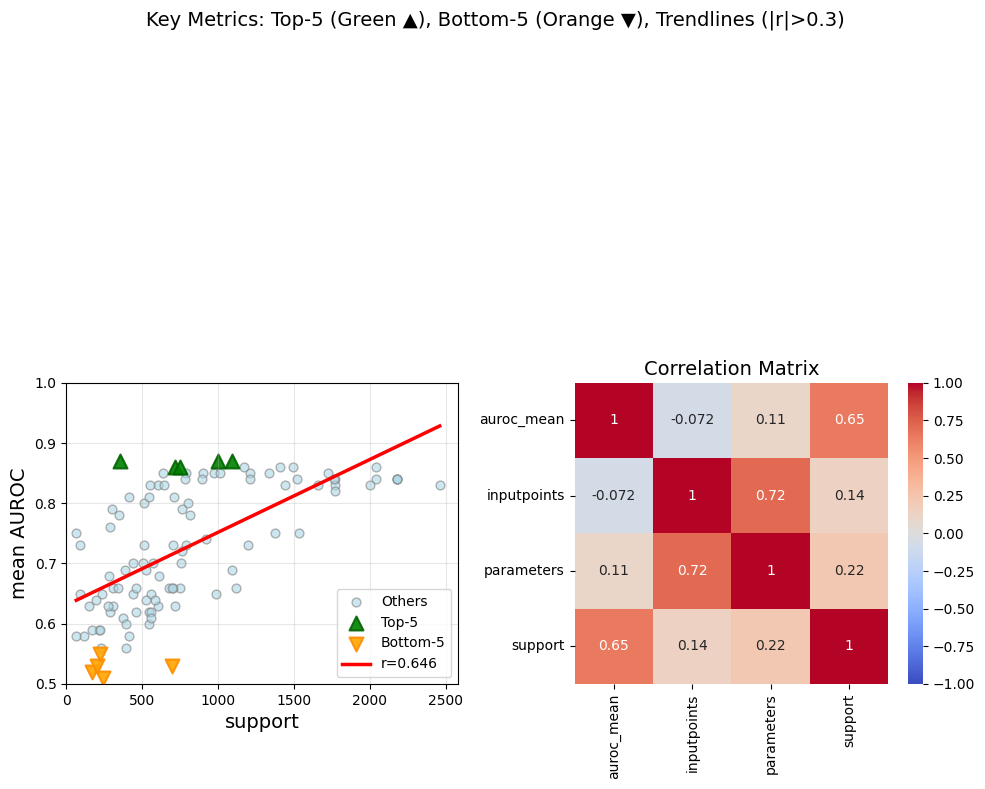

In [12]:
focus = ['auroc_mean', 'inputpoints', 'parameters', 'support']

df_best = best_model.copy()

# Identify top/bottom 5
top5_idx = df_best.nlargest(5, 'auroc_mean').index
bottom5_idx = df_best.nsmallest(5, 'auroc_mean').index
others_idx = ~df_best.index.isin(top5_idx.union(bottom5_idx))

top5_ids = df_best.loc[top5_idx, 'HPO'].values.tolist()
top5_ids = [hpo.find_successor(hpo_id) for hpo_id in top5_ids]
print(top5_ids)
bottom5_ids = df_best.loc[bottom5_idx, 'HPO'].values.tolist()
print(bottom5_ids)
bottom5_ids = [hpo.find_successor(hpo_id) for hpo_id in bottom5_ids]
print(bottom5_ids)

# Summary (unchanged)
summary = df_best[focus].describe().round(3)
corr = df_best[focus].corr().round(3)

print('Dataset: 107 HPO experiments from ML tuning (age/gender/ethnicity features).')
print(summary)
print('\nCorrelations:\n', corr['auroc_mean'])

# Visualize with highlighting + trendlines
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors = {'top': 'green', 'bottom': 'orange', 'other': 'lightblue'}
for i, col in enumerate(focus[1:], 0):
    r = corr['auroc_mean'][col]
    ax = axes[i//2, i%2]
    if abs(r) > 0.3:
        # Scatter with colors
        ax.scatter(df_best.loc[others_idx, col], df_best.loc[others_idx, 'auroc_mean'],
                   c=colors['other'], alpha=0.6, s=40, label='Others', edgecolors='gray')
        ax.scatter(df_best.loc[top5_idx, col], df_best.loc[top5_idx, 'auroc_mean'],
                   c=colors['top'], alpha=0.9, s=100, marker='^', label='Top-5', edgecolors='darkgreen', linewidth=1.5)
        ax.scatter(df_best.loc[bottom5_idx, col], df_best.loc[bottom5_idx, 'auroc_mean'],
                   c=colors['bottom'], alpha=0.9, s=100, marker='v', label='Bottom-5', edgecolors='darkorange', linewidth=1.5)

        # Trendline if strong correlation
        r = corr['auroc_mean'][col]
        slope, intercept, r_val, p_val, _ = linregress(df_best[col], df_best['auroc_mean'])
        x_fit = np.linspace(df_best[col].min(), df_best[col].max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, 'red', linewidth=2.5, label=f'r={r:.3f}')

        ax.set_xlabel(col, fontsize=14)
        ax.set_ylabel('mean AUROC', fontsize=14)
        ax.set_xlim(0, df_best[col].max() * 1.05)
        ax.set_ylim(0.5, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        fig.delaxes(ax)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,1], vmin=-1, vmax=1)
axes[1,1].set_title('Correlation Matrix', fontsize=14)

plt.suptitle('Key Metrics: Top-5 (Green ▲), Bottom-5 (Orange ▼), Trendlines (|r|>0.3)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(publication_dir, 'pearson_correlation.png'))
plt.show()
plt.close()

In [13]:
# Sort by score ascending for horizontal bars (lowest at bottom)
best_model = best_model.sort_values(by=[metric_mean], ascending=True)

# # Horizontal bar plot with error bars
# fig, ax = plt.subplots(figsize=(6, 25))
#
# y_pos = range(len(best_model))
# bars = ax.barh(
#     y_pos,
#     best_model[metric_mean],
#     color='skyblue',
#     alpha=0.8,
#     capsize=3,
#     xerr=best_model[metric_std]  # optional: add error bars
# )
#
# # Labels
# ax.set_yticks(y_pos)
# ax.set_yticklabels(best_model['HPO'])
# ax.set_xlabel("AUROC (mean)")
# # ax.set_title(
# #     f"Best low-variance experiment per HPO (std <= {std_threshold})\n"
# #     f"by AUROC mean\n{best_model_config}"
# # )
# ax.set_xlim(0, 1)
#
# # Annotate each bar with experiment and score
# for i, (_, test_sample_row) in enumerate(best_model.iterrows()):
#     ax.text(
#         test_sample_row[metric_mean] - 0.015,
#         i,
#         f"{test_sample_row[metric_mean]:.3f}±{test_sample_row[metric_std]:.3f}",
#         va='center',
#         ha='right',
#         fontweight='bold',
#         fontsize=10
#     )
#
# plt.tight_layout()
# # plt.savefig(os.path.join(publication_dir, 'best_model_hpos.png'))
# plt.show()
# plt.close()

In [14]:
bm = best_model.sort_values(by=[metric_mean], ascending=False)
df_best_model_hpos = pd.DataFrame({
    #"HPO Description": [hpo.find_successor(id).name for id in bm['HPO'].tolist()],
    "HPO": bm["HPO"],
    "AUROC": bm["auroc"],
    "F1-Score": bm["f1_score"],
    "Precision": bm["precision"],
    "Recall": bm["recall"],
    "N": bm["support"].astype(int),
}).set_index('HPO')
df_best_model_hpos.index.name = None
df_best_model_hpos = pd.merge(df_best_model_hpos, prev_all_df, left_index=True, right_index=True, how='inner')
df_best_model_hpos.index = [all_hpos[i].name for i in df_best_model_hpos.index.tolist()]
latex = df_best_model_hpos.to_latex(float_format='%.2f', longtable=True, label='tab:best_model_hpos_appendix', caption='The results of all HPO models with the best configuration. The HPO terms in bold letters are leafs of the human phenotype ontology. N: Samples, Prev: Prevalence, Det. P: Detection Prevalence', column_format='r'+'c'*len(df_best_model_hpos.columns))

for lh in leaf_hpos:
    latex = latex.replace(f'{lh.name} ', f'\\textbf{{{lh.name}}} ')
latex = latex.replace(' ± ', '$\\pm$')

with open(os.path.join(publication_dir, 'best_model_hpos.tex'), 'w') as f:
    f.write(latex)

df_best_model_hpos

,AUROC,F1-Score,Precision,Recall,N,Prev,Det. P
Abnormality of globe location,0.87 ± 0.02,0.86 ± 0.03,0.89 ± 0.02,0.84 ± 0.04,998,0.5,0.473948
Abnormality of upper lip vermillion,0.87 ± 0.04,0.86 ± 0.06,0.86 ± 0.07,0.87 ± 0.09,352,0.5,0.508523
Abnormal eye morphology,0.87 ± 0.05,0.87 ± 0.05,0.88 ± 0.04,0.86 ± 0.08,1090,0.5,0.485321
Aplasia/Hypoplasia of the eyebrow,0.86 ± 0.04,0.86 ± 0.04,0.86 ± 0.03,0.87 ± 0.06,716,0.5,0.504190
Abnormal nasal base norphology,0.86 ± 0.03,0.86 ± 0.04,0.85 ± 0.06,0.87 ± 0.05,752,0.5,0.514628
...,...,...,...,...,...,...,...
Narrow face,0.55 ± 0.11,0.46 ± 0.27,0.44 ± 0.26,0.47 ± 0.28,222,0.5,0.427928
Narrow nasal bridge,0.53 ± 0.14,0.47 ± 0.28,0.41 ± 0.24,0.59 ± 0.40,200,0.5,0.540000
Thick eyebrow,0.53 ± 0.06,0.19 ± 0.31,0.28 ± 0.38,0.18 ± 0.34,694,0.5,0.155620
Hypotelorism,0.52 ± 0.08,0.28 ± 0.29,0.35 ± 0.33,0.26 ± 0.32,170,0.5,0.229412


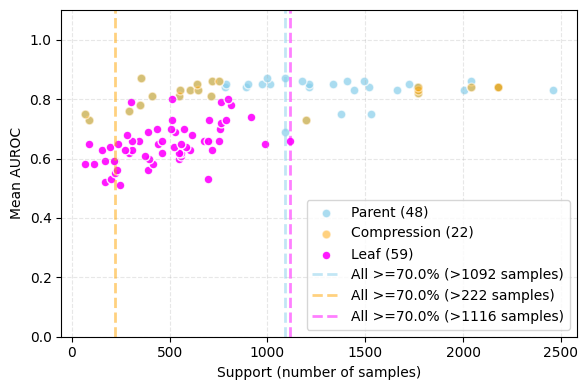

In [15]:
def find_threshold(df, group_mask, threshold):
    """Find smallest support where all points to RIGHT have score >= threshold."""
    group_df = df[group_mask].copy()
    return group_df[group_df[metric_mean] < threshold]['support'].max()

config = {p.split('=')[0]: p.split('=')[-1] for p in best_model_config.split('_')}
dimension = int(config['d'])
# face_outline = bool(config['f'])
meta_data = config['m'][1:-1].split('+')
# threshold = float(config['t'])
# softlabel = float(config['l'])

hpo_models = HumanPhenotypeModel.create_from_hpo(hp_abnorm_face, output_dir, dimensions=dimension, meta_data=meta_data, parallel=False, version=best_model_config, max_num_workers=1, recursive=True)
parent_hpo = [h.id for h in hpo_models.list_parent_nodes()]
compression_hpo = [h.id for h in hpo_models.list_compression_nodes()]
leaf_hpo = [h.id for h in hpo_models.list_leaf_nodes()]

# print(f'Number of available HPO-terms in total: {len([h for h in hpo_models.all_successors() if h.is_trained()])}')
#
# print(f'Parent HPO: {parent_hpo}')
# print(f'Compression HPO: {compression_hpo}')
# print(f'Leaf HPO: {leaf_hpo}')

# TODO Check
plt.figure(figsize=(6, 4))
mask_parent = best_model["HPO"].isin(parent_hpo)
plt.scatter(best_model.loc[mask_parent, "support"],
            best_model.loc[mask_parent, metric_mean],
            c='skyblue', alpha=0.7, s=40, edgecolors='white', label=f"Parent ({len(parent_hpo)})")

mask_compression = best_model["HPO"].isin(compression_hpo)
plt.scatter(best_model.loc[mask_compression, "support"],
            best_model.loc[mask_compression, metric_mean],
            c='orange', alpha=0.5, s=40, edgecolors='white', label=f"Compression ({len(compression_hpo)})")

mask_leaf = best_model["HPO"].isin(leaf_hpo)
plt.scatter(best_model.loc[mask_leaf, "support"],
            best_model.loc[mask_leaf, metric_mean],
            c='magenta', alpha=0.9, s=40, edgecolors='white', label=f"Leaf ({len(leaf_hpo)})")

# Calculate for both groups
threshold = 0.70
thresh_compression = find_threshold(best_model, mask_compression, threshold)
thresh_parent = find_threshold(best_model, mask_parent, threshold)
thresh_leaf = find_threshold(best_model, mask_leaf, threshold)

plt.axvline(x=thresh_parent, color='skyblue', linestyle='--', linewidth=2, alpha=0.5,
            label=f'All >={round(threshold * 100, 1)}% (>{int(thresh_parent)} samples)')
plt.axvline(x=thresh_compression, color='orange', linestyle='--', linewidth=2, alpha=0.5,
            label=f'All >={round(threshold * 100, 1)}% (>{int(thresh_compression)} samples)')
plt.axvline(x=thresh_leaf, color='magenta', linestyle='--', linewidth=2, alpha=0.5,
            label=f'All >={round(threshold * 100, 1)}% (>{int(thresh_leaf)} samples)')

plt.ylim(0, 1.1)
plt.xlabel("Support (number of samples)")
plt.ylabel(f"Mean AUROC")
# plt.title(f"Experiment: {best_model_config}\nMean {metric_mean} vs. Support")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(publication_dir, 'correlation_support_auroc.png'))
plt.show()
plt.close()

# Testing on "external" Dataset

In [16]:
reference_face_file = 'data/reference_face.jpg'

reference_face_mesh = extract_face_meshes([reference_face_file])
reference_face_mesh = reference_face_mesh[1].reshape((-1, 3))[:, :dimension]

Face Mesh Extraction: 100%|██████████| 1/1 [00:00<00:00, 128.01it/s]


In [17]:
all_hpos_available = {h.id: h for h in hpo.all_successors(with_self=True)}

def add_all_hpos(row):
    not_predictable = []
    hpos = set(ast.literal_eval(row['hpos']))
    for hpo_term in hpos.copy():
        if hpo_term in all_hpos_available:
            successor = all_hpos_available[hpo_term]
            predecessors = successor.predecessors()
            hpos.update([p.id for p in predecessors])
        else:
            not_predictable.append(hpo_term)
    row['name'] = int(row['name'])
    row['hpos'] = [h for h in list(hpos) if h not in not_predictable]
    if len(row['hpos']) > 0 and 'HP:0000271' not in row['hpos']:
        raise Exception(f'The {hpo.id} must be included in {row['hpos']}')
    return row

def load_annotations(annotators: int, drop_empty_hpos: bool = False):
    annotations = pd.read_csv(f'data/testing/Face2HPO/nih_hpo_labels_converted_1.06.2023_n{annotators}.tsv', sep='\t')
    # annotations['hpos_with_predecessors'] = None
    annotations = annotations.apply(add_all_hpos, axis=1)
    annotations['annotators'] = [annotators] * len(annotations)
    if drop_empty_hpos:
        annotations = annotations[annotations['hpos'].apply(len) > 0]
    return annotations

filter_empty_hpos = True
df = load_annotations(2, filter_empty_hpos).reset_index(drop=True) # pd.concat([load_annotations(n, filter_empty_hpos) for n in range(1, 4, 1)])

test_complete = set(df['name'].unique().tolist())

images = glob.glob('data/testing/**/*.jpg', recursive=True)
images = {int(pathlib.Path(image_path).stem): image_path for image_path in images if int(pathlib.Path(image_path).stem) in df['name'].tolist()}
images = {id: path for id, path in images.items() if id in df_gmdb['image_id'].tolist()}
print('Found: ', len(images), ' images')

df = df[df['name'].isin(images.keys())]
test_filtered = set(df['name'].unique().tolist())
print('Differences: ', test_complete - test_filtered)
print('Disorders: ', df['disorder_name'].unique().tolist())
print('Patients per Disorders: ', df['disorder_name'].value_counts())
df

Found:  75  images
Differences:  {1249, 2017, 8934, 1255, 8938, 4667, 5437}
Disorders:  ['Austism, susceptibility to', 'Coffin-Siris syndrome', 'Cornelia de Lange syndrome', 'FBXW7', 'FLOATING-HARBOR SYNDROME; FLHS', 'Hyperphosphatasia with mental retardation syndrome', 'KBG SYNDROME; KBGS', 'MOWAT-WILSON SYNDROME; MOWS', 'NICOLAIDES-BARAITSER SYNDROME; NCBRS', 'Noonan syndrome', 'OGDEN SYNDROME; OGDNS', 'OHDO SYNDROME, SBBYS VARIANT; SBBYSS', 'Opitz GBBB syndrome', 'SOTOS SYNDROME; SOTOS', 'Seckel syndrome', 'WHITE-SUTTON SYNDROME; WHSUS', 'WILLIAMS-BEUREN SYNDROME; WBS']
Patients per Disorders:  disorder_name
Coffin-Siris syndrome                                 10
Cornelia de Lange syndrome                             5
FBXW7                                                  5
FLOATING-HARBOR SYNDROME; FLHS                         5
Hyperphosphatasia with mental retardation syndrome     5
MOWAT-WILSON SYNDROME; MOWS                            5
OHDO SYNDROME, SBBYS VARIANT; SBBYSS   

,name,disorder_name,hpos,annotators
0,7258,"Austism, susceptibility to","[HP:0100886, HP:0000316, HP:0012372, HP:000027...",2
1,7263,"Austism, susceptibility to","[HP:0000159, HP:0000153, HP:0000271, HP:000017...",2
2,8862,Coffin-Siris syndrome,"[HP:0000153, HP:0031816, HP:0000508, HP:000528...",2
3,3515,Coffin-Siris syndrome,"[HP:0030669, HP:0010938, HP:0000153, HP:000031...",2
4,10144,Coffin-Siris syndrome,"[HP:0010938, HP:0000153, HP:0031816, HP:000017...",2
...,...,...,...,...
77,7997,WHITE-SUTTON SYNDROME; WHSUS,"[HP:0010938, HP:0000153, HP:0031816, HP:000047...",2
78,5008,WILLIAMS-BEUREN SYNDROME; WBS,"[HP:0000153, HP:0004428, HP:0031816, HP:000017...",2
79,4991,WILLIAMS-BEUREN SYNDROME; WBS,"[HP:0000159, HP:0000496, HP:0000153, HP:000023...",2
80,4982,WILLIAMS-BEUREN SYNDROME; WBS,"[HP:0030669, HP:0010938, HP:0000153, HP:000031...",2


In [18]:
image_ids, face_meshes = extract_face_meshes(list(images.values()))
face_mesh_dict = {int(image_id): torch.tensor(procrustes_align(face_mesh.reshape(-1, dimension), reference_face_mesh).reshape(dimension, -1)[:dimension, :], dtype=torch.float).reshape((dimension, -1)) for image_id, face_mesh in zip(image_ids, face_meshes)}

{key: value.shape for key, value in face_mesh_dict.items()}

Face Mesh Extraction: 100%|██████████| 75/75 [00:00<00:00, 94.04it/s]


{10120: torch.Size([3, 478]),
 10144: torch.Size([3, 478]),
 12774: torch.Size([3, 478]),
 2719: torch.Size([3, 478]),
 2721: torch.Size([3, 478]),
 3034: torch.Size([3, 478]),
 3515: torch.Size([3, 478]),
 7120: torch.Size([3, 478]),
 7441: torch.Size([3, 478]),
 8862: torch.Size([3, 478]),
 12875: torch.Size([3, 478]),
 12877: torch.Size([3, 478]),
 12879: torch.Size([3, 478]),
 12906: torch.Size([3, 478]),
 12911: torch.Size([3, 478]),
 7258: torch.Size([3, 478]),
 7263: torch.Size([3, 478]),
 4906: torch.Size([3, 478]),
 4916: torch.Size([3, 478]),
 5090: torch.Size([3, 478]),
 7281: torch.Size([3, 478]),
 8517: torch.Size([3, 478]),
 10802: torch.Size([3, 478]),
 10810: torch.Size([3, 478]),
 10815: torch.Size([3, 478]),
 10829: torch.Size([3, 478]),
 10835: torch.Size([3, 478]),
 12779: torch.Size([3, 478]),
 2331: torch.Size([3, 478]),
 3300: torch.Size([3, 478]),
 3347: torch.Size([3, 478]),
 7744: torch.Size([3, 478]),
 8919: torch.Size([3, 478]),
 8927: torch.Size([3, 478]),


In [19]:
df_meta = df_gmdb[df_gmdb['image_id'].isin(face_mesh_dict.keys())]
meta_data = {'age': df_meta['age'].tolist(), 'gender': df_meta['gender'].tolist(), 'ethnicity': df_meta['ethnicity'].tolist()}
meta_data['age'] = torch.stack([torch.tensor(a, dtype=torch.float) if not math.isnan(a) else torch.tensor(-1, dtype=torch.float) for a in meta_data['age']])
meta_data['gender'] = torch.stack([torch.tensor(gender_mapping[g], dtype=torch.float) for g in meta_data['gender']])
meta_data['ethnicity'] = torch.stack([torch.tensor(ethnicity_mapping[e], dtype=torch.float) for e in meta_data['ethnicity']])
{key: value.shape for key, value in meta_data.items()}

{'age': torch.Size([75]),
 'gender': torch.Size([75]),
 'ethnicity': torch.Size([75])}

In [20]:
result = hpo_models.predict(torch.stack(list(face_mesh_dict.values())), use_metric='matthews_corrcoef', **meta_data)

result

2026-04-21 12:47:16.586 | WARNING  | lib.hpo_tree.hpo_model:predict:392 - HP:0410030 (Cleft lip) is not trained yet.
2026-04-21 12:47:42.141 | WARNING  | lib.hpo_tree.hpo_model:predict:392 - HP:0004493 (Craniofacial hyperostosis) is not trained yet.


{HP:0000271 (Abnormality of the face): array([[0.8917641 ],
        [0.82131696],
        [0.7044234 ],
        [0.919347  ],
        [0.85945135],
        [0.8494725 ],
        [0.91958165],
        [0.851094  ],
        [0.7185451 ],
        [0.8156665 ],
        [0.5740742 ],
        [0.75943464],
        [0.7458832 ],
        [0.8664513 ],
        [0.88303035],
        [0.88434106],
        [0.77630633],
        [0.6676253 ],
        [0.67944926],
        [0.7731934 ],
        [0.8381284 ],
        [0.77083683],
        [0.21930742],
        [0.0260109 ],
        [0.44074667],
        [0.19001408],
        [0.19624382],
        [0.87938946],
        [0.8911913 ],
        [0.9324366 ],
        [0.8951862 ],
        [0.84904134],
        [0.77185917],
        [0.06850667],
        [0.6368988 ],
        [0.85758173],
        [0.09488572],
        [0.7038443 ],
        [0.8447653 ],
        [0.91452396],
        [0.05171499],
        [0.87999326],
        [0.86530507],
        [0.87554

In [21]:
all_results = {}
for idx, test_sample_row in enumerate(df.iterrows()):
    test_sample_row = test_sample_row[1]
    disorder = test_sample_row['disorder_name']
    if disorder not in all_results:
        all_results[disorder] = []
    image_result = {}
    for key, value in result.items():
        image_result[key.id] = 1 if np.mean(value[idx]) > 0.5 else 0
    all_results[disorder].append(image_result)
all_results = {d: pd.DataFrame(ar).transpose() for d, ar in all_results.items()}
all_results

{'Austism, susceptibility to':             0  1
 HP:0000271  1  1
 HP:0000153  1  1
 HP:0031816  1  1
 HP:0000163  1  1
 HP:0000159  1  1
 ...        .. ..
 HP:0000280  1  1
 HP:0000325  1  1
 HP:0004428  1  1
 HP:0012368  0  0
 HP:0004493  0  0
 
 [109 rows x 2 columns],
 'Coffin-Siris syndrome':             0  1  2  3  4  5  6  7  8  9
 HP:0000271  1  1  1  1  1  1  1  1  1  1
 HP:0000153  1  1  1  1  1  1  1  1  1  1
 HP:0031816  1  1  1  1  1  1  1  1  1  1
 HP:0000163  0  1  1  1  1  1  1  1  1  1
 HP:0000159  1  1  1  1  1  1  1  1  1  1
 ...        .. .. .. .. .. .. .. .. .. ..
 HP:0000280  0  1  1  1  1  1  1  1  0  1
 HP:0000325  0  1  1  1  1  1  0  1  0  1
 HP:0004428  0  1  1  1  1  1  1  1  0  1
 HP:0012368  0  0  0  0  0  0  0  0  0  0
 HP:0004493  0  0  0  0  0  0  0  0  0  0
 
 [109 rows x 10 columns],
 'Cornelia de Lange syndrome':             0  1  2  3  4
 HP:0000271  1  1  1  1  1
 HP:0000153  1  1  1  1  1
 HP:0031816  1  1  1  1  1
 HP:0000163  1  1  1  1  1
 HP:0

In [22]:
test_gt = {}
for disorder, data_df in all_results.items():
    rows = df[df['disorder_name'] == disorder]
    classified_hpos = data_df.index.tolist()
    gt = {h: [] for h in classified_hpos}
    for idx, r in rows.iterrows():
        for h in classified_hpos:
            if h in r['hpos']:
                gt[h].append(1)
            else:
                gt[h].append(0)
    test_gt[disorder] = pd.DataFrame(gt).transpose()
test_gt

{'Austism, susceptibility to':             0  1
 HP:0000271  1  1
 HP:0000153  0  1
 HP:0031816  0  1
 HP:0000163  0  1
 HP:0000159  0  1
 ...        .. ..
 HP:0000280  0  0
 HP:0000325  0  0
 HP:0004428  0  0
 HP:0012368  0  0
 HP:0004493  0  0
 
 [109 rows x 2 columns],
 'Coffin-Siris syndrome':             0  1  2  3  4  5  6  7  8  9
 HP:0000271  1  1  1  1  1  1  1  1  1  1
 HP:0000153  1  1  1  1  1  1  1  1  1  1
 HP:0031816  1  1  1  1  1  1  1  1  1  1
 HP:0000163  1  1  1  1  1  1  1  1  1  1
 HP:0000159  1  1  1  1  1  1  1  1  1  1
 ...        .. .. .. .. .. .. .. .. .. ..
 HP:0000280  0  1  1  0  0  0  1  1  1  1
 HP:0000325  0  0  0  0  0  0  0  0  0  0
 HP:0004428  0  0  0  0  0  0  0  0  0  0
 HP:0012368  0  0  0  0  0  0  0  0  0  0
 HP:0004493  0  0  0  0  0  0  0  0  0  0
 
 [109 rows x 10 columns],
 'Cornelia de Lange syndrome':             0  1  2  3  4
 HP:0000271  1  1  1  1  1
 HP:0000153  1  1  1  1  1
 HP:0031816  1  1  1  1  1
 HP:0000163  1  1  1  1  1
 HP:0

In [23]:
all_test_results_scores = {d: {id: {} for id in r.index.tolist()} for d, r in test_gt.items()}
overview_test_results = {d: {id: {} for id in r.index.tolist()} for d, r in test_gt.items()}
for disorder in test_gt.keys():
    gt_df = test_gt[disorder]
    pred_df = all_results[disorder]
    hpo_indices = gt_df.index.tolist()
    for id in hpo_indices:
        gt = gt_df.loc[id].values
        pred = pred_df.loc[id].values
        auroc = roc_auc_score(gt, pred, labels=[0, 1])
        f1 = f1_score(gt, pred, labels=[0, 1])
        p = precision_score(gt, pred, labels=[0, 1])
        r = recall_score(gt, pred, labels=[0, 1])
        matrix = confusion_matrix(gt, pred, labels=[0, 1])
        FP = matrix.sum(axis=0) - np.diag(matrix)
        FN = matrix.sum(axis=1) - np.diag(matrix)
        TP = np.diag(matrix)
        TN = matrix.sum() - (FP + FN + TP)
        # We only look into the positive class
        FP = FP[1]
        FN = FN[1]
        TP = TP[1]
        TN = TN[1]

        # F1-Score
        F1 = (2*TP)/(2*TP+FP+FN)
        # Sensitivity, hit rate, recall, or true positive rate
        TPR = TP/(TP+FN)
        # Specificity or true negative rate
        TNR = TN/(TN+FP)
        # Precision or positive predictive value
        PPV = TP/(TP+FP)
        # Negative predictive value
        NPV = TN/(TN+FN)
        # Fall out or false positive rate
        FPR = FP/(FP+TN)
        # False negative rate
        FNR = FN/(TP+FN)
        # False discovery rate
        FDR = FP/(TP+FP)
        # Overall accuracy
        ACC = (TP+TN)/(TP+FP+FN+TN)
        # Prevalence
        prev = (TP + FN) / (TP + FN + TN + FP)  # prevalence
        # Detection Prevalence
        prev_det = (TP + FP) / (TP + FN + TN + FP)  # detection prevalence

        all_test_results_scores[disorder][id] = {
            'AUROC': auroc if not np.isnan(auroc) else 'N/A',
            'F1': F1 if not np.isnan(F1) else 'N/A',
            'Prec': PPV if not np.isnan(PPV) else 'N/A',
            'Reca': TPR if not np.isnan(TPR) else 'N/A',
            # 'Spec': TNR if not np.isnan(TNR) else 'N/A',
            'N': len(gt),
            'Prev': prev,
            'Det. P': prev_det,
        }
        overview_test_results[disorder][id] = f1 if prev > 0 else -1

for disorder, data in all_test_results_scores.items():
    all_test_results_scores_df = pd.DataFrame(data).transpose()
    all_test_results_scores_df['N'] = all_test_results_scores_df['N'].astype(int)
    all_test_results_scores_df = all_test_results_scores_df[all_test_results_scores_df['Prev'] > 0]
    all_test_results_scores_df.index = [all_hpos[i].name for i in all_test_results_scores_df.index.tolist()]
    latex = all_test_results_scores_df.to_latex(float_format='%.2f', longtable=len(all_test_results_scores_df) > 40, caption=f'Prediction results on the test set for {disorder}. The HPO terms in bold letters are leafs of the human phenotype ontology. Acc: Accuracy, F1: F1-Score, Prec: Precision, Reca: Recall, N: Samples, Prev: Prevalence, Det. P: Detection Prevalence.', label=f'tab:pred_result_{disorder[:5].replace(" ", "")}', column_format='r'+'c'*len(all_test_results_scores_df.columns))

    for lh in leaf_hpos:
        latex = latex.replace(f'{lh.name} ', f'\\textbf{{{lh.name}}} ')
    latex = latex.replace(' ± ', '$\\pm$')

    disorder_name = disorder.replace(";", "_").replace("/", "_").replace(",", "_").replace(" ", "")
    with open(os.path.join(publication_dir, f'test_set_results_{disorder_name}.tex'), 'w') as f:
        f.write(latex)
    # all_test_results_scores_df.to_csv(os.path.join(publication_dir, f'test_set_results_{disorder.replace(";", "_").replace("/", "_").replace(",", "_")}.csv'), index_label='ID')

overview_test_results_df = pd.DataFrame(overview_test_results)
left_column = {}
right_column = {}
for c in overview_test_results_df.columns:
    if c in train_val_disorders:
        right_column[c] = c[:3]
    else:
        left_column[c] = c[:3]
all_columns = {}
all_columns.update(left_column)
all_columns.update(right_column)

overview_test_results_df = overview_test_results_df[all_columns.keys()]
overview_test_results_df.rename(columns=all_columns, inplace=True)
overview_test_results_df = overview_test_results_df[(overview_test_results_df != -1).any(axis=1)]
overview_test_results_df.index = [all_hpos[i].name for i in overview_test_results_df.index.tolist()]
# latex = overview_test_results_df.to_latex(float_format='%.2f', longtable=True, caption=f'Overview of the disorders performance in the test set based on their F1-score. The disorders on the right side, after the separator, are included in the train/val set too. The disorders on the left side are only in the test set. The names of the disorders are: {", ".join([f"{v}: {k}" for k, v in all_columns.items()])}.', label='tab:overview_test_results_all_appendix', column_format='r'+'c'*len(left_column)+'|'+'c'*len(right_column))
#
# for lh in leaf_hpos:
#     latex = latex.replace(f'{lh.name} ', f'\\textbf{{{lh.name}}} ')
# latex = latex.replace(' ± ', '$\\pm$')
#
# with open(os.path.join(publication_dir, 'overview_test_results.tex'), 'w') as f:
#     f.write(latex)

print('All tables created and saved!')

All tables created and saved!


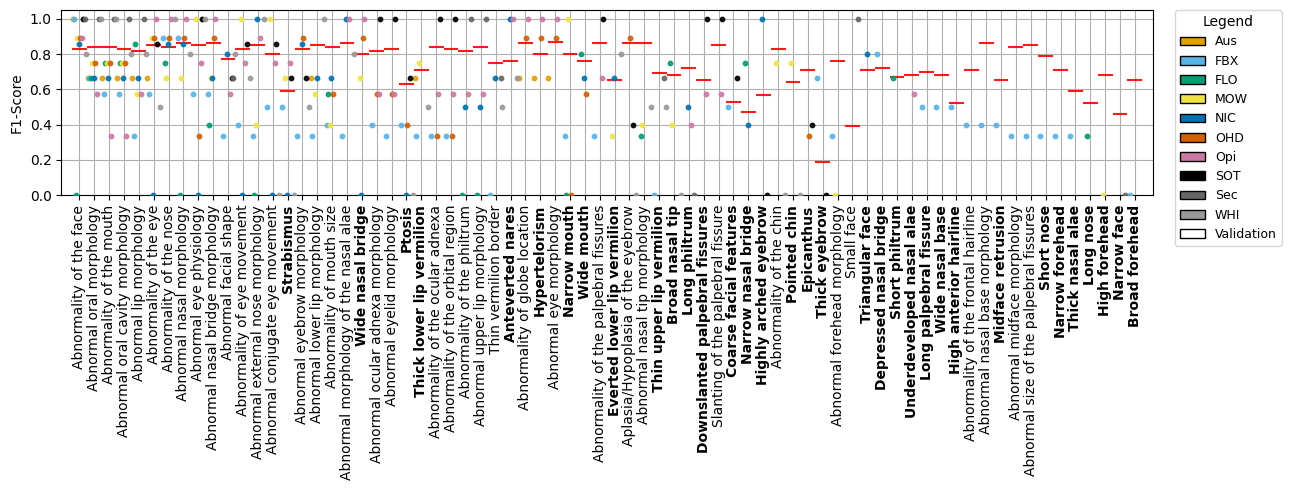

In [24]:
new_disorders_results_df = overview_test_results_df[left_column.values()]
# new_disorders_results_df = new_disorders_results_df[(new_disorders_results_df != 0).any(axis=1)]

leaf_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h in leaf_hpos]
parent_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h not in leaf_hpos]
sorted_leaf_rows_idx = new_disorders_results_df.loc[leaf_rows_idx].mean(axis=1).sort_values(ascending=True).index.tolist()
sorted_parent_rows_idx = new_disorders_results_df.loc[parent_rows_idx].mean(axis=1).sort_values(ascending=False).index.tolist()
new_disorders_results_df = new_disorders_results_df.reindex(sorted_parent_rows_idx + sorted_leaf_rows_idx)
new_disorders_results_df = new_disorders_results_df[(new_disorders_results_df != -1).any(axis=1)]

cols = new_disorders_results_df.columns.tolist()
n_cols = len(cols)

# Set2 colors, fixed per disorder
# cmap = plt.colormaps["tab20"]
# colors = [cmap(i / max(n_cols - 1, 1)) for i in range(n_cols)]
colors = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000",
    "#666666", "#999999",
]

# Per-HPO mean performance and metric_value (F1-Score) from df_best_model_hpos
row_means = new_disorders_results_df.mean(axis=1).values
metric_values = []
for hpo_name in new_disorders_results_df.index:
    raw = str(df_best_model_hpos.loc[hpo_name]["F1-Score"])
    # supports formats like "0.726 ± 0.063" or "0.726 0.063"
    mv = float(raw.replace("±", " ").split()[0])
    metric_values.append(mv)
metric_values = np.array(metric_values)

# x-positions for each HPO term
x = np.arange(len(new_disorders_results_df.index))

# global y limit
global_max = max(new_disorders_results_df.values.max(), metric_values.max()) * 1.05

fig, ax = plt.subplots(figsize=(13, 5))

# 1) Main bars: mean per row (over disorders)
bar_width = 1
# ax.bar(
#     x,
#     row_means,
#     width=bar_width,
#     color="#DDDDDD",
#     edgecolor="black",
#     alpha=0.8,
#     label="Mean over disorders",
# )

# 2) Threshold line per bar (metric_value)
for xi, mv in zip(x, metric_values):
    ax.hlines(
        mv,
        xi - bar_width / 2,
        xi + bar_width / 2,
        colors="red",
        linestyles="solid",
        linewidth=1.5,
        alpha=0.9,
    )

# 3) Inside-bar values: per-disorder scores as points
inner_width = bar_width / max(n_cols, 3)
offsets = (np.arange(n_cols) - (n_cols - 1) / 2) * inner_width

for j, col in enumerate(cols):
    vals = new_disorders_results_df[col].values
    x_inner = x + offsets[j]
    ax.scatter(
        x_inner,
        vals,
        color=colors[j],
        s=10,
        alpha=0.9,
        zorder=3,
    )

# x-axis labels: HPO names
ax.set_xticks(x)
ax.set_xticklabels(new_disorders_results_df.index, rotation=90, fontsize=10)

# highlight labels that are leaf HPO terms by name
leaf_names = set([h.name for h in leaf_hpos])

for tick in ax.get_xticklabels():
    txt = tick.get_text()
    if txt in leaf_names:
        tick.set_fontweight("bold")
        # optional: change color too
        # tick.set_color("blue")

ax.set_ylim(0, global_max)
# ax.set_ylabel("Mean F1-Score / per-disorder F1-Score")
# ax.set_xlabel("HPO term")
ax.set_ylabel('F1-Score')

# Legend: disorders + mean + threshold
handles = [
    Patch(facecolor=colors[i], edgecolor="black", label=cols[i])
    for i in range(n_cols)
]
# handles.insert(
#     0,
#     Patch(facecolor="#DDDDDD", edgecolor="black", label="mean F1"),
# )

# add line handle for threshold
threshold_handle = Patch(facecolor="none", edgecolor="black", label="Validation")
handles.append(threshold_handle)

ax.legend(
    handles=handles,
    title="Legend",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    fontsize=9,
)

plt.margins(0.01)
plt.tight_layout()
plt.grid()
plt.savefig(os.path.join(publication_dir, "hpo_tree_flat_barplot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [25]:
new_disorders_results_df

,Aus,FBX,FLO,MOW,NIC,OHD,Opi,SOT,Sec,WHI
Abnormality of the face,1.000000,1.000000,0.000000,0.888889,0.857143,0.888889,0.888889,1.0,1.0,0.8
Abnormal oral morphology,0.666667,0.666667,0.666667,0.750000,0.666667,0.750000,0.571429,-1.0,1.0,1.0
Abnormality of the mouth,0.666667,0.571429,0.750000,0.750000,0.666667,0.750000,0.333333,-1.0,1.0,1.0
Abnormal oral cavity morphology,0.666667,0.571429,0.750000,0.750000,0.666667,0.750000,0.333333,-1.0,1.0,0.8
Abnormal lip morphology,0.666667,0.333333,0.857143,0.571429,0.666667,-1.000000,0.571429,-1.0,1.0,0.8
...,...,...,...,...,...,...,...,...,...,...
Thick nasal alae,-1.000000,0.333333,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0
Long nose,-1.000000,-1.000000,0.333333,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0
High forehead,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0
Narrow face,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,0.0,-1.0


In [ ]:
# from matplotlib.patches import Patch
#
# new_disorders_results_df = overview_test_results_df[left_column.values()]
# new_disorders_results_df = new_disorders_results_df[(new_disorders_results_df != 0).any(axis=1)]
#
# leaf_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h in leaf_hpos]
# parent_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h not in leaf_hpos]
# sorted_leaf_rows_idx = new_disorders_results_df.loc[leaf_rows_idx].mean(axis=1).sort_values(ascending=False).index.tolist()
# sorted_parent_rows_idx = new_disorders_results_df.loc[parent_rows_idx].mean(axis=1).sort_values(ascending=True).index.tolist()
# new_disorders_results_df = new_disorders_results_df.reindex(sorted_parent_rows_idx + sorted_leaf_rows_idx)
# mean_perform_disorders = new_disorders_results_df.mean(axis=0).sort_values(ascending=False)
#
# edges = [(h.id, h.predecessor.id) for h in all_hpos.values() if h.predecessor and any([True for n in new_disorders_results_df.index.tolist() if h.find_successor(n)])]
# root = hpo.find_root().id
#
# import networkx as nx
# import matplotlib.pyplot as plt
#
# G = nx.DiGraph()
# G.add_edges_from(edges)
#
# # simple top-down tree layout (using graphviz if available, or a fallback)
# try:
#     pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # (x,y) positions  twopi
# except Exception:
#     # fallback to hierarchical-ish layout
#     pos = nx.spring_layout(G, k=1.0, iterations=200)
#
# # normalize y so root is at top
# ys = [p[1] for p in pos.values()]
# y_min, y_max = min(ys), max(ys)
# for k, (x, y) in pos.items():
#     pos[k] = (x, y_max - y)  # invert y
#
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# import numpy as np
#
# fig, ax = plt.subplots(figsize=(15, 15))
#
# # draw edges
# for parent, child in G.edges():
#     x0, y0 = pos[parent]
#     x1, y1 = pos[child]
#     ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=1.0, zorder=1)
#
# # for each node, draw a small bar chart
# cols = new_disorders_results_df.columns.tolist()
# n_cols = len(cols)
# cmap = plt.colormaps["tab20"]      # or plt.get_cmap("Set2") in older Matplotlib
# colors = [cmap(i / max(n_cols - 1, 1)) for i in range(n_cols)]
#
# for node, (x, y) in pos.items():
#     hpo_name = all_hpos[node].name
#     if hpo_name in new_disorders_results_df.index.tolist():
#         values = new_disorders_results_df.loc[hpo_name].values
#         metric_value = float(df_best_model_hpos.loc[hpo_name]['F1-Score'].split(' ')[0])
#
#         axins = inset_axes(
#             ax,
#             width=1.0,   # size relative to figure
#             height=0.5,
#             bbox_to_anchor=(x, y - 12, 1, 1),
#             bbox_transform=ax.transData,
#             loc="center",
#             borderpad=0,
#         )
#
#         axins.bar(cols, values, color=colors, alpha=0.8)
#         axins.set_xticks([])
#         # axins.set_yticks([])
#         axins.set_xlim(-0.5, len(cols) - 0.5)
#         axins.set_ylim(0, new_disorders_results_df.values.max() * 1.05)
#
#         # --- threshold line at metric_value ---
#         axins.axhline(
#             metric_value,
#             color="red",
#             linestyle="--",
#             linewidth=1.2,
#             alpha=0.9,
#         )
#         # ---------------------------------------
#
#     ax.text(
#         x,
#         y + 0.3,  # tweak offset
#         hpo_name.replace('Abnormality', 'Abn.').replace('Abnormal', 'Abn.').replace('of ', '').replace('the ', ''),
#         fontsize=10,
#         ha="center",
#         va="bottom",
#     )
#
# ax.set_axis_off()
#
# # ---- Legend for disorders / columns -------------------------
# handles = [
#     Patch(facecolor=colors[i], edgecolor="black", label=cols[i])
#     for i in range(n_cols)
# ] + [Patch(linewidth=1, color='red', linestyle="--", fill=False, label='Validation')]
#
# # place legend outside the main tree
# ax.legend(
#     handles=handles,
#     title="Disorders",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     borderaxespad=0.0,
#     fontsize=12,
# )
#
#
# plt.tight_layout()
# plt.savefig(os.path.join(publication_dir, "tree_with_node_bars.png"), dpi=300, bbox_inches="tight")
# plt.show()
# plt.close()
# # df_best_model_hpos

In [ ]:
# new_disorders_results_df = overview_test_results_df[left_column.values()]
# new_disorders_results_df = new_disorders_results_df[(new_disorders_results_df != 0).any(axis=1)]
#
# leaf_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h in leaf_hpos]
# parent_rows_idx = [h for h in new_disorders_results_df.index.tolist() if h not in leaf_hpos]
# sorted_leaf_rows_idx = new_disorders_results_df.loc[leaf_rows_idx].mean(axis=1).sort_values(ascending=False).index.tolist()
# sorted_parent_rows_idx = new_disorders_results_df.loc[parent_rows_idx].mean(axis=1).sort_values(ascending=True).index.tolist()
# new_disorders_results_df = new_disorders_results_df.reindex(sorted_parent_rows_idx + sorted_leaf_rows_idx)
# mean_perform_disorders = new_disorders_results_df.mean(axis=0).sort_values(ascending=False)
# new_disorders_results_df = new_disorders_results_df[mean_perform_disorders.index.tolist()]
# new_disorders_results_df.columns = [f'{c} ({mean_perform_disorders.loc[c]:.03f})' for c in new_disorders_results_df.columns]
# # depth_info = [f'{h} #{all_hpos[h].level}' for h in new_disorders_results_df.index.tolist()]
# # new_disorders_results_df.index = depth_info
#
# n_points = new_disorders_results_df.shape[0]
# cols = new_disorders_results_df.columns
# n_cols = len(cols)
#
# angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
#
# fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
#
# # total angular space per HPO term
# sector_width = 2 * np.pi / n_points
# # how wide we want the group to be (fraction of sector)
# group_frac = 0.8
# group_width = sector_width * group_frac
# # per-column offset inside that group
# step = group_width / max(n_cols - 1, 1)
# offsets = (np.arange(n_cols) - (n_cols - 1) / 2) * step
#
# # plot points
# for i, col in enumerate(cols):
#     values = new_disorders_results_df[col].values
#     # shifted angles for this column
#     theta = angles + offsets[i]
#     ax.scatter(theta, values, label=col, s=30, alpha=0.8)
#
# row_means = new_disorders_results_df.mean(axis=1).values
# angles_mean_closed = np.concatenate([angles, angles[:1]])
# row_means_closed = np.concatenate([row_means, row_means[:1]])
# ax.plot(
#     angles_mean_closed,
#     row_means_closed,
#     color="gray",
#     linewidth=1,
#     alpha=0.8,
#     linestyle="--",
#     label="Mean",
#     zorder=5,
# )
#
# # radius limits
# r_max = new_disorders_results_df.values.max() * 1.1
# ax.set_ylim(0, r_max)
#
# # remove default xticks
# ax.set_xticks([])
#
# # custom labels, placed slightly outside the circle, rotated tangentially
# labels = new_disorders_results_df.index.tolist()
# r_label = r_max * 1.02  # a bit outside the data circle
#
# for angle, lab in zip(angles, labels):
#     # convert angle to degrees
#     ang_deg = np.degrees(angle)
#
#     # draw radial line from center to just before label
#     ax.plot([angle, angle], [0, r_label * 0.98], color="lightgray", linewidth=0.7, alpha=0.3)
#
#     # rotation so text is perpendicular to radius, but readable
#     rotation = ang_deg + 180
#     ha = "right"
#     ax.text(
#         angle,
#         r_label,
#         lab,
#         # style='italic' if lab in leaf_hpos else None,
#         fontweight='bold' if lab in leaf_hpos else None,
#         fontsize=10,
#         rotation=rotation,
#         rotation_mode="anchor",
#         ha=ha,
#         va="center",
#     )
#
# ax.grid(True, alpha=0.3)
# ax.legend(loc="upper left", bbox_to_anchor=(1.1, 1.2))
#
# plt.tight_layout()
# plt.savefig(os.path.join(publication_dir, "overview_test_results_new_disorders.png"), dpi=300)
# plt.show()
# plt.close()
# new_disorders_results_df

In [ ]:
# # Parse JSON column and explode into long format
# records = []
# for _, test_sample_row in all_results_df.iterrows():
#     hpos = test_sample_row['hpos']
#
#     for hpo_id, data in hpos.items():
#         records.append({
#             'image_id': test_sample_row['image_id'],
#             'disorder': test_sample_row['disorder'],
#             'hpo_id': hpo_id,
#             'description': data['description'],
#             'annotated': data['annotated'],
#             'predicted': np.mean(data['predicted'])
#         })
#
# df_long = pd.DataFrame(records)
#
# # Convert annotated to numeric (True=1, False=0)
# # df_long['annotated_numeric'] = df_long['annotated'].astype(int)
# # df_long['predicted_binary'] = (df_long['predicted'] > 0.5).astype(int)
#
#
# # Group by image
# image_groups = df_long.groupby('image_id')
# n_images = len(image_groups)
#
# # Grid: n_cols = min(4, n_images), adjust height
# n_cols = n_images
# n_rows = math.ceil(n_images / n_cols)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 + n_cols * 2, 20))
# if n_rows == 1 and n_cols == 1:
#     axes = [axes]
# else:
#     axes = axes.flatten()
#
# # Hide unused subplots
# for i in range(n_images, len(axes)):
#     axes[i].axis('off')
#
# for idx, (image_id, group) in enumerate(image_groups):
#     ax = axes[idx]
#
#     # Prepare horizontal data
#     hpo_ids = [str(h) for h in group['hpo_id'].values.tolist()]
#     predicted = group['predicted'].values.tolist()
#     annotated = group['annotated'].values.tolist()
#     hpo_labels = [f"{id} ({desc[:20]}...)" if len(desc) > 20 else f"{id} ({desc})"
#                   for id, desc in zip(hpo_ids, group['description'].values.tolist())]
#
#     # Colors by annotation level
#     bar_colors = ['lightgreen' if a == 3 else 'yellow' if a == 2 else
#                   'orange' if a == 1 else 'gray' for a in annotated]
#
#     # Horizontal bar plot
#     bars = ax.barh(hpo_labels, predicted, color=bar_colors, alpha=0.8,
#                    edgecolor='black', linewidth=0.3)
#
#     # Styling
#     ax.set_xlim(0, 1)
#     ax.set_xlabel('Predicted Score')
#     disorder_label = group['disorder'].iloc[0]
#     disorder_label = disorder_label if len(disorder_label) < 15 else f'{disorder_label[:15]}...'
#     ax.set_title(f"Image {image_id}\n({disorder_label})", fontweight='bold', pad=10)
#     ax.grid(axis='x', alpha=0.3)
#
#     # Only leftmost column gets y-label
#     if idx % n_cols == 0:
#         ax.set_ylabel('HPO Term')
#     else:
#         ax.set_yticklabels([])  # Hide y-ticks except left column
#
#     # Rotate x-ticks if needed
#     plt.setp(ax.get_xticklabels(), rotation=0)
#
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.2, wspace=0.1)
# plt.show()

In [ ]:
# test_set_results = {}
#
# def analyze_disease(imgs, hpo_nrs, add_hpo_terms):
#     hpo_ids = [f'HP:{nr:07d}' for nr in hpo_nrs]
#     hpo_ids_add = [f'HP:{nr:07d}' for nr in add_hpo_terms]
#
#     all_results = {}
#
#     for img_id in imgs:
#         rows = df_long[df_long['image_id'] == img_id]
#         img_results = {}
#         for hpo_id in hpo_ids:
#             pred_result = rows[rows['hpo_id'] == hpo_id]
#             if len(pred_result) > 0:
#                 pred_result = pred_result['predicted'].iloc[0]
#             else:
#                 pred_result = -1.0
#             img_results.update({hpo_id: pred_result})
#         for hpo_id in hpo_ids_add:
#             pred_result = rows[rows['hpo_id'] == hpo_id]
#             if len(pred_result) > 0:
#                 pred_result = pred_result['predicted'].iloc[0]
#             else:
#                 pred_result = -1.0
#             img_results.update({hpo_id: pred_result})
#         all_results.update({img_id: img_results})
#     all_results_df = pd.DataFrame(all_results)
#     tp_sum = (all_results_df > 0.5).sum(axis=1)
#     tn_sum = (0 <= all_results_df).sum(axis=1) - tp_sum
#     all_results_df['tp'] = tp_sum
#     all_results_df['fn'] = tn_sum
#
#     # Add all results to the overall result dict
#     for hpo_id, row in all_results_df.iterrows():
#         if hpo_id not in test_set_results:
#             test_set_results.update({hpo_id: {'tp': 0, 'fn': 0}})
#         test_set_results[hpo_id]['tp'] += row['tp']
#         test_set_results[hpo_id]['fn'] += row['fn']
#
#     return all_results_df

In [ ]:
# # Alpha-thalassemia-X-linked intellectual disability syndrome	ALPHA-THALASSEMIA/MENTAL RETARDATION SYNDROME, X-LINKED; ATRX
# ATRX_imgs = [9237]
# ATRX_hpos = [158, 164, 179, 232, 252, 271, 286, 316, 457, 463, 506, 10804, 10806, 11800, 12368]
# additional_terms = []
#
# analyze_disease(ATRX_imgs, ATRX_hpos, additional_terms)

In [ ]:
# # Autism, susceptibility to	Autism, susceptiblity to
# Autism_imgs = [7255, 7258, 7260, 7263, 7267]
# Autism_hpos = []
# additional_terms = [316, 506, 11232, 179]
#
# analyze_disease(Autism_imgs, Autism_hpos, additional_terms)

In [ ]:
# # Cornelia de Lange syndrome	Cornelia de Lange syndrome
# CDLS_imgs = [4906, 4916, 5090, 7281, 8517]
# CDLS_hpos = [233, 252, 294, 343, 347, 368, 400, 463, 470, 486, 498, 574, 664, 667, 687, 508, 527, 2553, 2714, 3196, 5280, 7665]
# additional_terms = []
#
# analyze_disease(CDLS_imgs, CDLS_hpos, additional_terms)

In [ ]:
# # Floating-Harbor syndrome	FLOATING-HARBOR SYNDROME; FLHS
# FLHS_imgs = [10802, 10810, 10815, 10829, 10835]
# FLHS_hpos = [154, 325, 470, 486, 322, 327, 369, 446, 455, 490, 670, 677, 691, 3189, 9765]
# additional_terms = [194, 411, 160]
#
# analyze_disease(FLHS_imgs, FLHS_hpos, additional_terms)

In [ ]:
# # Hyperphosphatasia-intellectual disability syndrome	Hyperphosphatasia with mental retardation syndrome
# Hyperphosphatasia_imgs = [2331, 3300, 3347, 7744, 12779]
# Hyperphosphatasia_hpos = [316, 431, 637, 1999, 2714, 10804, 218, 248, 280, 286, 289, 303, 311, 322, 347, 378, 391, 414, 426, 470, 565, 582, 1357, 2553, 40194, 40195]
# additional_terms = [465, 194, 10808, 9909, 508, 194, 9909, 508, 9748, 233, 319]
#
# analyze_disease(Hyperphosphatasia_imgs, Hyperphosphatasia_hpos, additional_terms)

In [ ]:
# # KBG syndrome	KBG SYNDROME; KBGS
# KGBS_imgs = [8919, 8927, 8928, 8934, 8938]
# KGBS_hpos = [343, 400, 426, 430, 463, 465, 470, 486, 506, 574, 637, 664, 677, 1566, 1572, 219, 252, 316, 325, 10720, 311, 272, 322, 325, 369, 965, 1072, 12471, 12745, 40196, 45025, 45075, 315, 486, 11220]
# additional_terms = [11232, 582, 414]
#
# analyze_disease(KGBS_imgs, KGBS_hpos, additional_terms)

In [ ]:
# # Mowat-Wilson syndrome	MOWAT-WILSON SYNDROME; MOWS
# MOWS_imgs = [3360, 6947, 8582, 8850, 10134]
# MOWS_hpos = [179, 194, 232, 252, 276, 303, 307, 316, 358, 431, 437, 486, 490, 506, 9765, 9909, 11228, 11229, 568, 612, 678, 684, 687, 692]
# additional_terms = [194, 10808, 160, 455, 11232, 348, 2209]
#
# analyze_disease(MOWS_imgs, MOWS_hpos, additional_terms)

In [ ]:
# # Nicolaides-Baraitser syndrome	NICOLAIDES-BARAITSER SYNDROME; NCBRS
# NCBRS_imgs = [2656, 4667, 4673, 4724, 4765]
# NCBRS_hpos = [154, 232, 233, 252, 319, 325, 343, 463, 1006, 1596, 9928, 10529, 446, 527, 581, 2553, 7392, 7665, 10720, 12745, 494]
# additional_terms = [430, 635, 7651, 194, 508, 431, 486]
#
# analyze_disease(NCBRS_imgs, NCBRS_hpos, additional_terms)

In [ ]:
# # Noonan syndrome	Noonan syndrome
# Noonan_imgs = [1741, 3164, 5020, 8145, 8886]
# Noonan_hpos = [179, 316, 325, 347, 348, 368, 391, 465, 486, 494, 508, 520, 2208, 11362, 11800]
# additional_terms = [194, 286, 337, 215, 463, 322, 2553]
#
# analyze_disease(Noonan_imgs, Noonan_hpos, additional_terms)

In [ ]:
# # Ogden syndrome	OGDEN SYNDROME; OGDNS
# OGDNS_imgs = [5399, 5421, 5437, 8946, 8948]
# OGDNS_hpos = [473, 2213, 100840, 280, 290, 308, 341, 369, 400, 430, 494, 520, 973, 2000, 2007, 9931, 10803]
# additional_terms = [508, 463, 348, 343, 219, 7413, 303, 490, 276, 687, 486]
#
# analyze_disease(OGDNS_imgs, OGDNS_hpos, additional_terms)

In [ ]:
# # Barber-Say syndrome	OHDO SYNDROME, SBBYS VARIANT; SBBYSS
# SBBYSS_imgs = [10967, 10974, 10984, 10987, 11008]
# SBBYSS_hpos = [154, 271, 316, 377, 414, 431, 463, 506, 656, 974, 1582, 2230, 8065, 11224, 100840, 200102]
# additional_terms = [194, 10808, 508, 45025, 687, 286, 160]
#
# analyze_disease(SBBYSS_imgs, SBBYSS_hpos, additional_terms)

In [ ]:
# # Opitz GBBB syndrome	Opitz GBBB syndrome
# GBBB_imgs = [5610, 5618, 5620, 5622, 13060]
# GBBB_hpos = [316, 343, 431, 11220, 349, 463, 506, 508, 1999, 2119, 410030, 252, 347, 358, 369, 494, 4467, 5487, 486, 668]
# additional_terms = [194, 430, 411, 494, 527, 10808]
#
# analyze_disease(GBBB_imgs, GBBB_hpos, additional_terms)

In [ ]:
# # Sotos syndrome	SOTOS SYNDROME; SOTOS
# SOTOS_imgs = [2628, 2631, 3368, 3419, 7666]
# SOTOS_hpos = [280, 268, 275, 276, 494, 4768, 11220, 40194, 400000, 164, 256, 486, 668, 953, 1010, 1028]
# additional_terms = [508, 574, 2553, 10282, 100840, 194, 460, 414, 286]
#
# analyze_disease(SOTOS_imgs, SOTOS_hpos, additional_terms)

In [ ]:
# # Seckel syndrome	Seckel syndrome
# Seckel_imgs = [13118, 13119]
# Seckel_hpos = [252, 275, 347, 363, 387, 444, 494, 682, 2209, 7495, 9804, 10579]
# additional_terms = [194, 343, 273, 219]
#
# analyze_disease(Seckel_imgs, Seckel_hpos, additional_terms)

In [ ]:
# # White-Sutton syndrome	WHITE-SUTTON SYNDROME; WHSUS
# WHSUS_imgs = [2017, 2022, 2023, 7997]
# WHSUS_hpos = [252, 1513, 1999, 160, 194, 219, 248, 307, 486, 11800, 272, 297, 322, 358, 455, 470, 612, 1045, 2714, 5280]
# additional_terms = [687, 100840, 463, 4768, 45074, 508, 11232, 10806, 232, 414, 179, 455]
#
# analyze_disease(WHSUS_imgs, WHSUS_hpos, additional_terms)

In [ ]:
# # Williams syndrome	WILLIAMS-BEUREN SYNDROME; WBS
# WBS_imgs = [69, 4982, 4991, 5008]
# WBS_hpos = [154, 158, 179, 212, 232, 252, 275, 280, 286, 307, 337, 343, 347, 348, 368, 400, 411, 431, 464, 486, 501, 581, 635, 668, 670, 682, 689, 691, 1052, 1582, 3196, 4428, 6482, 7495, 7957, 10669, 10807, 100539]
# additional_terms = [11232, 5280, 563, 687, 508]
#
# analyze_disease(WBS_imgs, WBS_hpos, additional_terms)

In [ ]:
# final_result = pd.DataFrame(test_set_results).transpose()
# final_result['true_positive_rate'] = final_result['tp'] / (final_result['tp'] + final_result['fn'])
# final_result['false_negative_rate'] = 1 - final_result['true_positive_rate']
# final_result = final_result.dropna()
# final_result

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(6, 14))
#
# # Horizontal bars: TP (green), FN (red)
# y_pos = np.arange(len(final_result))
# final_result_sorted = final_result.sort_values(by=['true_positive_rate'], ascending=True)
# width_tp = final_result_sorted['true_positive_rate']
# width_fn = final_result_sorted['false_negative_rate']
#
# bars_tp = ax.barh(y_pos, width_tp, label='True Positive Rate (Sensitivity)', color='lightgreen', alpha=0.8, height=0.3)
# # bars_fn = ax.barh(y_pos - 0.3, width_fn, label='False Negative Rate', color='salmon', alpha=0.8, height=0.3)
#
# # Styling
# ax.set_yticks(y_pos)
# ax.set_yticklabels([str(all_hpos_available[h]) for h in final_result_sorted.index], fontsize=11)
# ax.set_xlabel('True Positive Rate (Sensitivity)', fontsize=12)
# ax.set_title('HPO Performance on "external" Test Set', fontsize=14, fontweight='bold', pad=20)
# ax.grid(axis='x', alpha=0.3)
# ax.set_xlim(0, 1)
# plt.tight_layout()
# plt.show()

# Export the best HPO-models in onnx format to use them in a webpage

In [37]:
models_dir = os.path.join('models')
os.makedirs(models_dir, exist_ok=True)
hpo_models.export_to_onnx(models_dir, recursive=True, optimize=False)
HumanPhenotypeModel.export_results_json(hpo_models, reference_face_mesh, output_dir=models_dir)

[torch.onnx] Obtain model graph for `FaceMeshLightningModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FaceMeshLightningModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 19 of general pattern rewrite rules.
[torch.onnx] Obtain model graph for `FaceMeshLightningModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FaceMeshLightningModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 19 of general pattern rewrite rules.
[torch.onnx] Obtain model graph for `FaceMeshLightningModule([...]` with `torch.export.export(..., strict=Fals

2026-04-21 15:07:51.626 | DEBUG    | lib.hpo_tree.hpo_model:export_results_json:614 - HPO tree data exported to models\result.json


#### Compare ONNX and PyTorch Models for equal results

In [38]:
import onnxruntime as ort

sample_images = ['data/47.png', 'data/6.png', 'data/8.png', 'data/32.png']
count_sample_images = len(sample_images)
sample_meshes = extract_face_meshes(sample_images)
sample_meshes = sample_meshes[1].reshape((count_sample_images, -1, 3))[:, :, :dimension]
sample_meshes_preprocessed = np.asarray([procrustes_align(sample_mesh.reshape(-1, dimension), reference_face_mesh).reshape(dimension, -1)[:dimension, :]])

sample_input_tensor = torch.tensor(
    procrustes_align(sample_meshes.reshape(count_sample_images, -1, dimension), reference_face_mesh).reshape(count_sample_images, dimension, -1)[:dimension, :], dtype=torch.float).reshape((count_sample_images, dimension, -1))
zero_tensor = torch.tensor([0, 0], dtype=torch.float)
minus_one_tensor = torch.tensor([-1, -1], dtype=torch.float)
sample_input_meta = {'age': zero_tensor.clone(), 'gender': minus_one_tensor.clone(), 'ethnicity': minus_one_tensor.clone()}
sample_pred = hpo_models.predict(sample_input_tensor, use_metric='matthews_corrcoef', **sample_input_meta)

pred_prepared = {k: v[0][0].item() for k, v in sample_pred.items() if k.is_trained()}
# pd.DataFrame(data=pred_prepared.values(), index=pred_prepared.keys())

onnx_pred = {k: 0 for k in pred_prepared.keys()}
for n in onnx_pred.keys():
    if n.is_trained():
        point_mask = np.load(n.point_mask_file_input)
        batch_size = sample_input_tensor.shape[0]
        reduced_facemeshes = sample_input_tensor.reshape(batch_size, -1, dimension)
        reduced_facemeshes = reduced_facemeshes[:,point_mask]
        reduced_facemeshes = reduced_facemeshes.reshape(batch_size, dimension, -1)

        sess = ort.InferenceSession(f'models/{n.id.replace(':', '_')}.onnx')
        onnx_logit = sess.run(None, {
            "input":     reduced_facemeshes.numpy().astype(np.float32),
            "age":       sample_input_meta['age'].numpy().astype(np.float32),
            "gender":    sample_input_meta['gender'].numpy().astype(np.float32),
            "ethnicity": sample_input_meta['ethnicity'].numpy().astype(np.float32),
        })[0]
        onnx_pred[n] = torch.sigmoid(torch.tensor(onnx_logit[0].item(), dtype=torch.float)).item()

compare = {k.name: [pred_prepared[k], onnx_pred[k]] for k in onnx_pred.keys()}
df_test_results = pd.DataFrame(compare.values(), index=compare.keys(), columns=['PyTorch', 'ONNX'])
df_test_results['max |Δ|'] = (df_test_results['PyTorch'] - df_test_results['ONNX']).abs().max()
df_test_results

Face Mesh Extraction: 100%|██████████| 4/4 [00:00<00:00, 76.74it/s]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 478 is different from 4)